<a href="https://colab.research.google.com/github/Amankumar201140/-Load-Forecasting-using-Deep-Neural-Netwoks/blob/main/Copy_of_Untitled7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

data = pd.read_csv('/content/continuous dataset.csv')
data.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [ ]:
data['datetime'] = pd.to_datetime(data['datetime'])

In [ ]:
data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['dayofweek'] = data['datetime'].dt.dayofweek

In [ ]:
target = 'nat_demand'

In [ ]:
data['lag1'] = data[target].shift(1)
data['lag24'] = data[target].shift(24)
data['lag168'] = data[target].shift(168)  # weekly pattern

In [ ]:
data.dropna(inplace=True)

In [ ]:
print(data.columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour', 'day',
       'month', 'dayofweek', 'lag1', 'lag24', 'lag168'],
      dtype='object')


In [ ]:
data.drop(['datetime'], axis=1, inplace=True)

In [ ]:
data.drop(['Holiday_ID'], axis=1, inplace=True)

In [ ]:
X = data.drop('nat_demand', axis=1)
y = data['nat_demand']

In [ ]:
X.head()

,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,...,W2M_dav,holiday,school,hour,day,month,dayofweek,lag1,lag24,lag168
168,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,0.015735,...,6.229961,0,0,1,10,1,5,949.5031,943.6081,970.3450
169,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,0.015712,...,6.395434,0,0,2,10,1,5,906.9580,917.0640,912.1755
170,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,0.015704,...,6.426799,0,0,3,10,1,5,863.5135,895.9092,900.2688
171,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,0.015704,...,6.351922,0,0,4,10,1,5,848.4447,885.2720,889.9538
172,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,0.015735,...,6.165582,0,0,5,10,1,5,839.8821,884.8111,893.6865


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 20.586077298088195
RMSE: 28.641507564650723


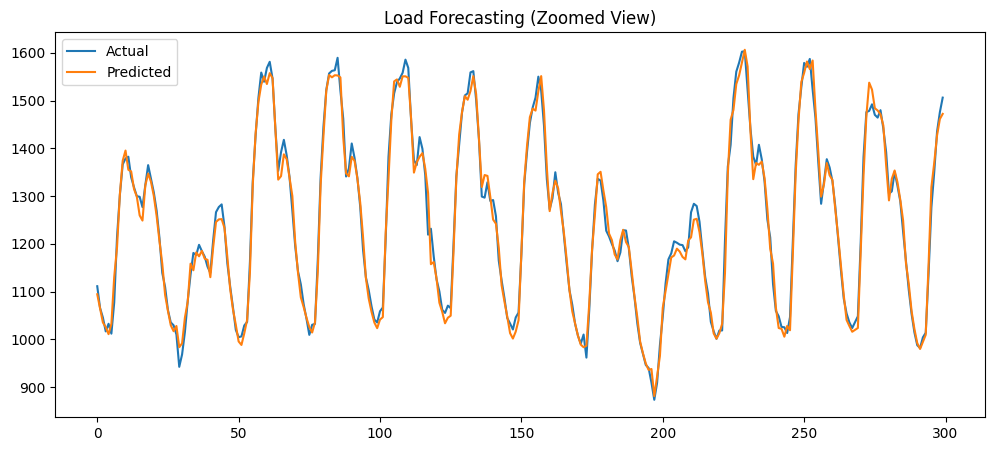

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:300], label='Actual')
plt.plot(y_pred[:300], label='Predicted')

plt.legend()
plt.title("Load Forecasting (Zoomed View)")
plt.show()